Creating Performance Comparison Plot...
Creating Overfitting Analysis...
Creating Sample Size Impact Analysis...
ADVANCED AUGMENTATION PERFORMANCE ANALYSIS


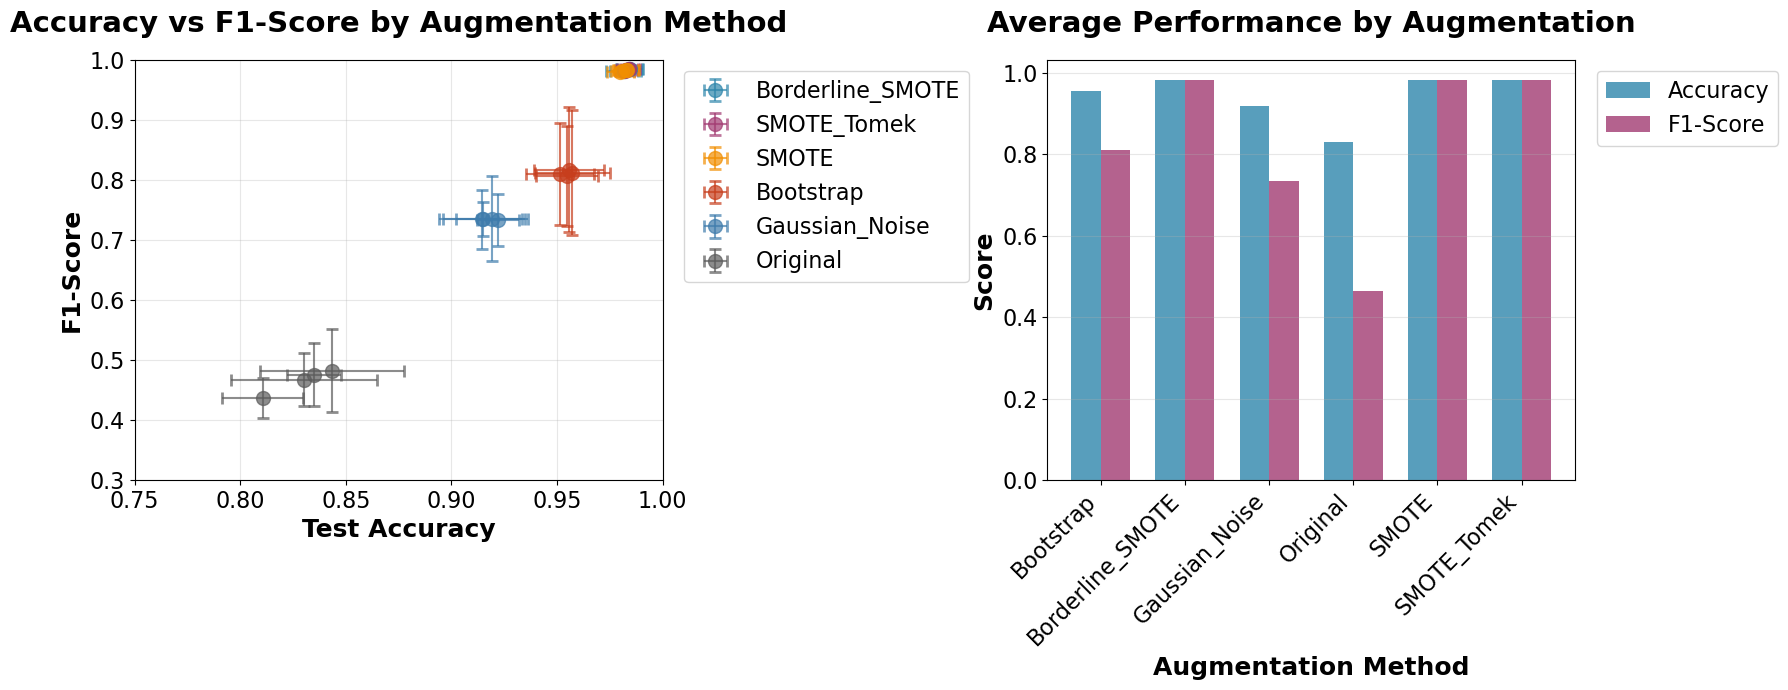

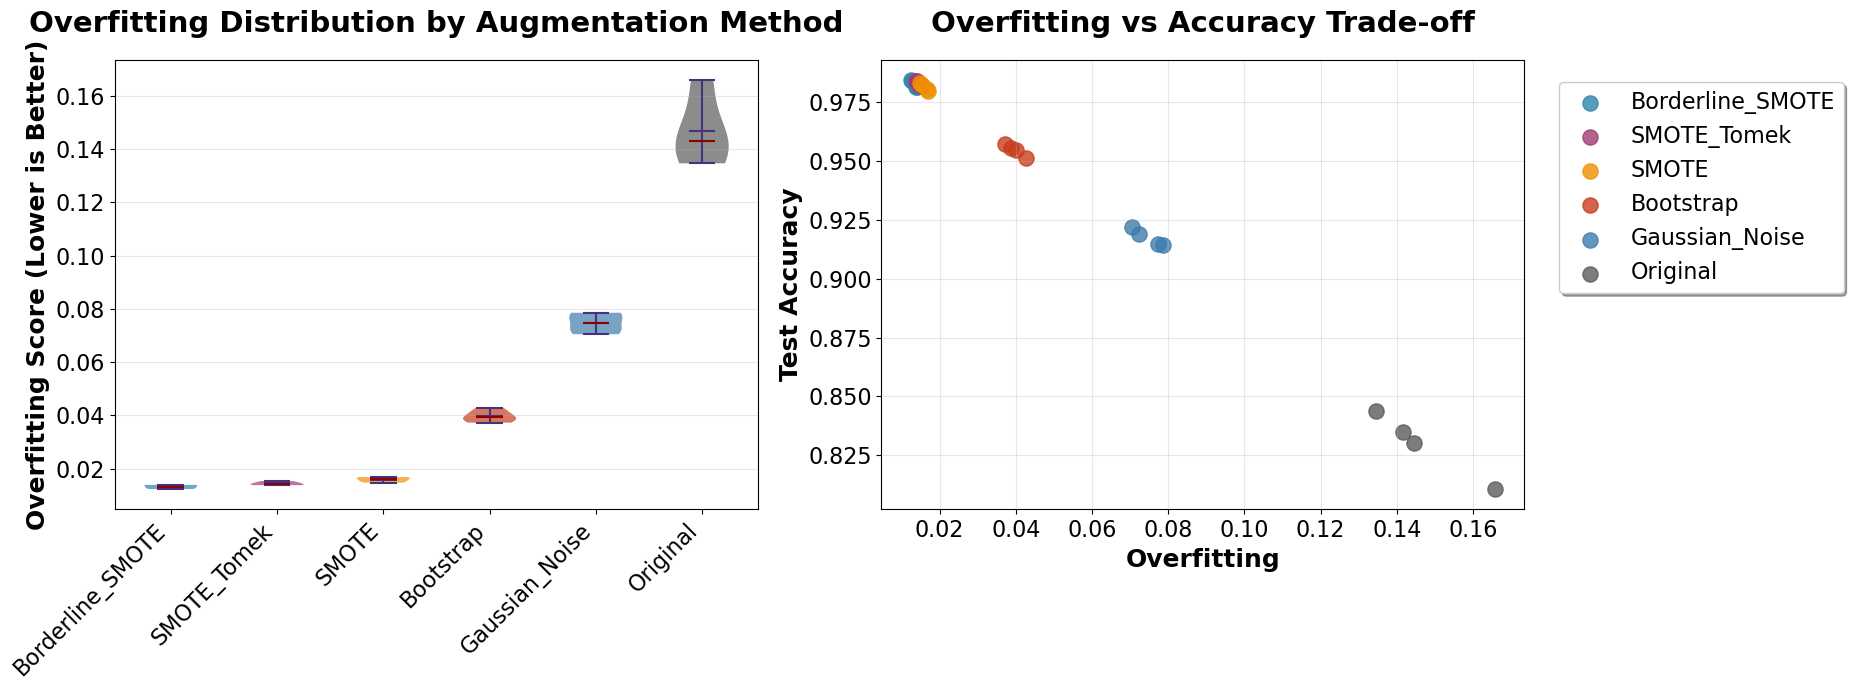


Overfitting Statistics by Augmentation Method:
                    Mean     Std     Min     Max
Augmentation                                    
Borderline_SMOTE  0.0132  0.0008  0.0124  0.0140
SMOTE_Tomek       0.0145  0.0007  0.0139  0.0154
SMOTE             0.0160  0.0010  0.0148  0.0169
Bootstrap         0.0397  0.0023  0.0373  0.0427
Gaussian_Noise    0.0747  0.0039  0.0705  0.0785
Original          0.1466  0.0134  0.1346  0.1658


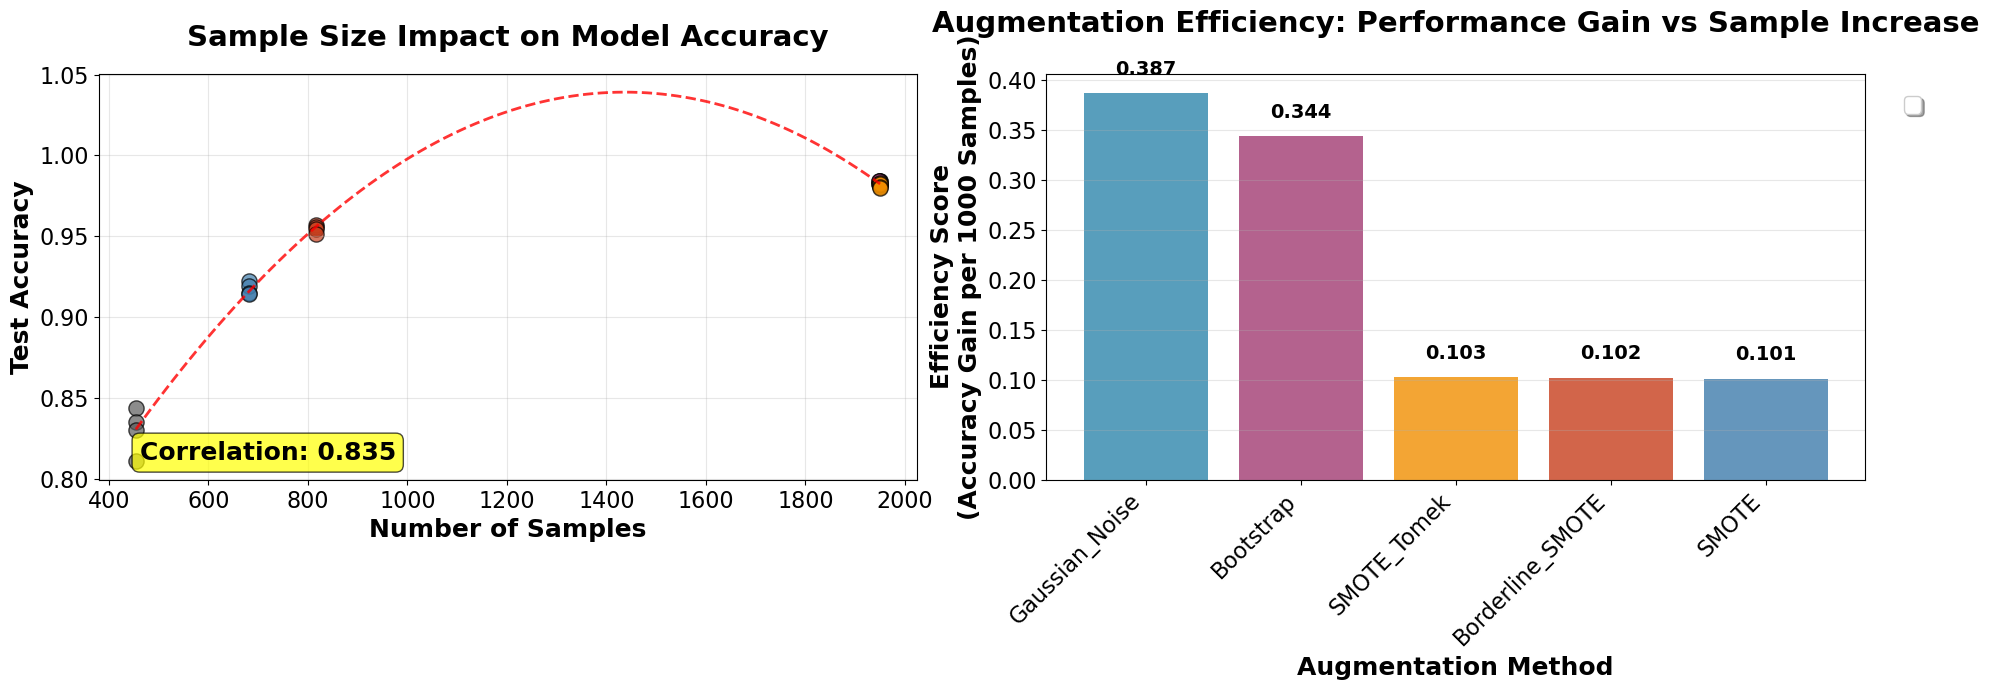


KEY INSIGHTS SUMMARY

Top 3 Performing Configurations:
                                       Configuration     Augmentation  Test_Accuracy  Test_F1  Overfitting
Borderline_SMOTE_Extra_Trees_RepeatedStratifiedKFold Borderline_SMOTE       0.984444 0.984468     0.012393
      Borderline_SMOTE_Extra_Trees_StratifiedKFold_5 Borderline_SMOTE       0.984103 0.984106     0.012821
           SMOTE_Tomek_Extra_Trees_StratifiedKFold_5      SMOTE_Tomek       0.984089 0.984084     0.013857

Augmentation Method Summary:
                 Test_Accuracy         Test_F1         Overfitting Samples
                          mean     std    mean     std        mean    mean
Augmentation                                                              
Bootstrap               0.9547  0.0024  0.8111  0.0045      0.0397   817.0
Borderline_SMOTE        0.9829  0.0015  0.9830  0.0015      0.0132  1950.0
Gaussian_Noise          0.9177  0.0037  0.7343  0.0010      0.0747   681.0
Original                0.8298  0.01

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Create the dataframe with new data
data = {
    'Configuration': [
        'Borderline_SMOTE_Extra_Trees_RepeatedStratifiedKFold', 'Borderline_SMOTE_Extra_Trees_StratifiedKFold_5',
        'SMOTE_Tomek_Extra_Trees_StratifiedKFold_5', 'SMOTE_Tomek_Extra_Trees_RepeatedStratifiedKFold',
        'SMOTE_Extra_Trees_RepeatedStratifiedKFold', 'SMOTE_Extra_Trees_StratifiedKFold_5',
        'SMOTE_Tomek_Random_Forest_RepeatedStratifiedKFold', 'SMOTE_Tomek_Random_Forest_StratifiedKFold_5',
        'Borderline_SMOTE_Random_Forest_RepeatedStratifiedKFold', 'Borderline_SMOTE_Random_Forest_StratifiedKFold_5',
        'SMOTE_Random_Forest_StratifiedKFold_5', 'SMOTE_Random_Forest_RepeatedStratifiedKFold',
        'Bootstrap_Extra_Trees_StratifiedKFold_5', 'Bootstrap_Extra_Trees_RepeatedStratifiedKFold',
        'Bootstrap_Random_Forest_StratifiedKFold_5', 'Bootstrap_Random_Forest_RepeatedStratifiedKFold',
        'Gaussian_Noise_Extra_Trees_StratifiedKFold_5', 'Gaussian_Noise_Extra_Trees_RepeatedStratifiedKFold',
        'Gaussian_Noise_Random_Forest_StratifiedKFold_5', 'Gaussian_Noise_Random_Forest_RepeatedStratifiedKFold',
        'Original_Extra_Trees_RepeatedStratifiedKFold', 'Original_Extra_Trees_StratifiedKFold_5',
        'Original_Random_Forest_RepeatedStratifiedKFold', 'Original_Random_Forest_StratifiedKFold_5'
    ],
    'Augmentation': ['Borderline_SMOTE']*2 + ['SMOTE_Tomek']*2 + ['SMOTE']*2 + ['SMOTE_Tomek']*2 + ['Borderline_SMOTE']*2 + 
                   ['SMOTE']*2 + ['Bootstrap']*4 + ['Gaussian_Noise']*4 + ['Original']*4,
    'Model': ['Extra_Trees']*2 + ['Extra_Trees']*2 + ['Extra_Trees']*2 + ['Random_Forest']*2 + ['Random_Forest']*2 + 
             ['Random_Forest']*2 + ['Extra_Trees']*2 + ['Random_Forest']*2 + ['Extra_Trees']*2 + ['Random_Forest']*2 + 
             ['Extra_Trees']*2 + ['Random_Forest']*2,
    'CV_Strategy': ['RepeatedStratifiedKFold', 'StratifiedKFold_5'] * 12,
    'Samples': [1950, 1950, 1948, 1948, 1950, 1950, 1948, 1948, 1950, 1950, 1950, 1950, 
                817, 817, 817, 817, 681, 681, 681, 681, 454, 454, 454, 454],
    'Features': [50]*24,
    'Test_Accuracy': [0.984444444, 0.984102564, 0.984089381, 0.983914925, 0.983076923, 0.982564103, 
                     0.982373827, 0.982036781, 0.981709402, 0.981538462, 0.980512821, 0.98,
                     0.957197366, 0.955558881, 0.954728415, 0.95146142, 0.9221769, 0.919246458,
                     0.914866896, 0.914358809, 0.843573464, 0.834749695, 0.83033781, 0.810549451],
    'Accuracy_Std': [0.006450585, 0.005936327, 0.004403811, 0.005337415, 0.005906719, 0.005936327,
                    0.004949826, 0.004277978, 0.006677615, 0.008332347, 0.004755702, 0.006363935,
                    0.017626224, 0.016709524, 0.014729856, 0.016000852, 0.00994194, 0.016923885,
                    0.018736317, 0.020298642, 0.034140203, 0.012800286, 0.03459301, 0.019129719],
    'Test_F1': [0.984468273, 0.984106033, 0.984083989, 0.983880335, 0.983041158, 0.982522993,
               0.982345578, 0.982013708, 0.981733848, 0.981532643, 0.980476662, 0.979968787,
               0.811674445, 0.816800845, 0.805881244, 0.809900949, 0.732972957, 0.734907436,
               0.735315385, 0.734086648, 0.481776027, 0.47528107, 0.46665663, 0.436150094],
    'F1_Std': [0.006359683, 0.005914949, 0.004372022, 0.005321652, 0.005902427, 0.005992393,
              0.004913437, 0.004211774, 0.006570773, 0.00829238, 0.004751245, 0.006300915,
              0.104336051, 0.104180357, 0.08312616, 0.085184089, 0.042892199, 0.07069833,
              0.028244326, 0.048585013, 0.068996217, 0.052079976, 0.04423814, 0.032933065],
    'Precision': [0.985128419, 0.984719499, 0.984597044, 0.984348017, 0.983598138, 0.983148708,
                 0.982833877, 0.982550019, 0.982572174, 0.982338762, 0.980948099, 0.980501106,
                 0.849537327, 0.849997424, 0.855322872, 0.856570597, 0.801340314, 0.786269417,
                 0.791314147, 0.780275027, 0.51543544, 0.503612424, 0.491952196, 0.456682543],
    'Recall': [0.984444444, 0.984102564, 0.984067197, 0.983884468, 0.983076923, 0.982564103,
              0.982340112, 0.982015915, 0.981709402, 0.981538462, 0.980512821, 0.98,
              0.806915855, 0.812300105, 0.801573975, 0.801596148, 0.706849653, 0.716668702,
              0.720729477, 0.722314638, 0.475647001, 0.471027392, 0.469543469, 0.443454433],
    'Overfitting': [0.012393162, 0.012820513, 0.013857362, 0.014031681, 0.014786325, 0.015512821,
                   0.014717201, 0.015396649, 0.013803419, 0.013974359, 0.016666667, 0.016880342,
                   0.037293363, 0.038626663, 0.040067188, 0.0427235, 0.070480278, 0.072308678,
                   0.077422635, 0.078542792, 0.134586255, 0.141578522, 0.144515619, 0.165772712]
}

df = pd.DataFrame(data)

# Set style
plt.style.use('default')
sns.set_palette("viridis")

# ============================================================================
# 1. PERFORMANCE COMPARISON: Accuracy vs F1-Score by Augmentation Method
# ============================================================================
print("Creating Performance Comparison Plot...")

def create_performance_comparison():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    colors = {'Borderline_SMOTE': '#2E86AB', 'SMOTE_Tomek': '#A23B72', 'SMOTE': '#F18F01', 
              'Bootstrap': '#C73E1D', 'Gaussian_Noise': '#3F7CAC', 'Original': '#5B5B5B'}

    # Plot 1: Accuracy vs F1
    for augmentation in df['Augmentation'].unique():
        subset = df[df['Augmentation'] == augmentation]
        ax1.errorbar(subset['Test_Accuracy'], subset['Test_F1'],
                     xerr=subset['Accuracy_Std'], yerr=subset['F1_Std'],
                     fmt='o', label=augmentation, color=colors[augmentation],
                     alpha=0.7, markersize=10, capsize=4, capthick=2)
    ax1.set_xlabel('Test Accuracy', fontsize=18, fontweight='bold')
    ax1.set_ylabel('F1-Score', fontsize=18, fontweight='bold')
    ax1.set_title('Accuracy vs F1-Score by Augmentation Method', fontsize=21, fontweight='bold', pad=20)
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=16)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.75, 1.0)
    ax1.set_ylim(0.3, 1.0)
    ax1.tick_params(axis='both', which='major', labelsize=16)

    # Plot 2: Averages
    avg_perf = df.groupby('Augmentation').agg({'Test_Accuracy': 'mean', 'Test_F1': 'mean'}).reset_index()
    x = np.arange(len(avg_perf))
    width = 0.35
    bars1 = ax2.bar(x - width/2, avg_perf['Test_Accuracy'], width, label='Accuracy', color='#2E86AB', alpha=0.8)
    bars2 = ax2.bar(x + width/2, avg_perf['Test_F1'], width, label='F1-Score', color='#A23B72', alpha=0.8)
    ax2.set_xlabel('Augmentation Method', fontsize=18, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=18, fontweight='bold')
    ax2.set_title('Average Performance by Augmentation', fontsize=21, fontweight='bold', pad=20)
    ax2.set_xticks(x)
    ax2.set_xticklabels(avg_perf['Augmentation'], rotation=45, ha='right', fontsize=16)
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=16)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.tick_params(axis='y', labelsize=16)

    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()

# ============================================================================
# 2. AVERAGE OVERFITTING BY AUGMENTATION METHOD
# ============================================================================
print("Creating Overfitting Analysis...")

def create_overfitting_analysis():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # Plot 1: Overfitting distribution by augmentation
    overfitting_stats = df.groupby('Augmentation').agg({
        'Overfitting': ['mean', 'std', 'min', 'max']
    }).round(4)
    overfitting_stats.columns = ['Mean', 'Std', 'Min', 'Max']
    overfitting_stats = overfitting_stats.sort_values('Mean')
    
    # Create enhanced violin plot
    box_data = [df[df['Augmentation'] == aug]['Overfitting'].values 
                for aug in overfitting_stats.index]
    
    violin_parts = ax1.violinplot(box_data, positions=range(len(overfitting_stats.index)), 
                                 showmeans=True, showmedians=True)
    
    # Color the violins
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3F7CAC', '#5B5B5B']
    for patch, color in zip(violin_parts['bodies'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Color the median lines
    violin_parts['cmedians'].set_colors(['darkred'] * len(overfitting_stats.index))
    
    ax1.set_title('Overfitting Distribution by Augmentation Method', 
                 fontsize=21, fontweight='bold', pad=20)
    ax1.set_ylabel('Overfitting Score (Lower is Better)', fontsize=18, fontweight='bold')
    ax1.set_xticks(range(len(overfitting_stats.index)))
    ax1.set_xticklabels(overfitting_stats.index, rotation=45, ha='right', fontsize=16)
    ax1.tick_params(axis='y', labelsize=16)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Overfitting vs Performance trade-off
    for augmentation in df['Augmentation'].unique():
        subset = df[df['Augmentation'] == augmentation]
        ax2.scatter(subset['Overfitting'], subset['Test_Accuracy'], 
                   label=augmentation, s=120, alpha=0.8, color=colors[list(df['Augmentation'].unique()).index(augmentation)])
    
    ax2.set_xlabel('Overfitting', fontsize=18, fontweight='bold')
    ax2.set_ylabel('Test Accuracy', fontsize=18, fontweight='bold')
    ax2.set_title('Overfitting vs Accuracy Trade-off', fontsize=21, fontweight='bold', pad=20)
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=1.0,
               frameon=True, fancybox=True, shadow=True, fontsize=16)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='both', labelsize=16)
    
    # # Add ideal direction annotation
    # ax2.annotate('Ideal: High Accuracy\nLow Overfitting', 
    #             xy=(0.02, 0.95), xycoords='axes fraction',
    #             fontsize=15, ha='left', va='top',
    #             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Make space for legends
    plt.show()
    
    # Print overfitting statistics
    print("\nOverfitting Statistics by Augmentation Method:")
    print("="*50)
    print(overfitting_stats.to_string())

# ============================================================================
# 3. SAMPLE SIZE IMPACT ON ACCURACY
# ============================================================================
print("Creating Sample Size Impact Analysis...")

def create_sample_size_impact():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7))
    
    # Plot 1: Sample size vs Accuracy with trend line
    colors = {'Borderline_SMOTE': '#2E86AB', 'SMOTE_Tomek': '#A23B72', 'SMOTE': '#F18F01', 
              'Bootstrap': '#C73E1D', 'Gaussian_Noise': '#3F7CAC', 'Original': '#5B5B5B'}
    
    for augmentation in df['Augmentation'].unique():
        subset = df[df['Augmentation'] == augmentation]
        ax1.scatter(subset['Samples'], subset['Test_Accuracy'], 
                   label=augmentation, s=120, alpha=0.7, edgecolors='black',
                   color=colors[augmentation])
    
    # Add trend line
    z = np.polyfit(df['Samples'], df['Test_Accuracy'], 2)
    p = np.poly1d(z)
    x_trend = np.linspace(df['Samples'].min(), df['Samples'].max(), 100)
    ax1.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend Line')
    
    ax1.set_xlabel('Number of Samples', fontsize=18, fontweight='bold')
    ax1.set_ylabel('Test Accuracy', fontsize=18, fontweight='bold')
    ax1.set_title('Sample Size Impact on Model Accuracy', fontsize=21, fontweight='bold', pad=20)
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=1.0,
           frameon=True, fancybox=True, shadow=True, fontsize=16)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='both', labelsize=16)
    
    # Add correlation coefficient
    correlation = np.corrcoef(df['Samples'], df['Test_Accuracy'])[0,1]
    ax1.annotate(f'Correlation: {correlation:.3f}', 
                xy=(0.05, 0.05), xycoords='axes fraction',
                fontsize=18, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    
    # Plot 2: Augmentation efficiency (Performance gain per sample)
    augmentation_efficiency = []
    baseline_accuracy = df[df['Augmentation'] == 'Original']['Test_Accuracy'].mean()
    
    for augmentation in df['Augmentation'].unique():
        if augmentation != 'Original':
            aug_data = df[df['Augmentation'] == augmentation]
            avg_accuracy = aug_data['Test_Accuracy'].mean()
            avg_samples = aug_data['Samples'].mean()
            efficiency = (avg_accuracy - baseline_accuracy) / (avg_samples - 454) * 1000  # per 1000 samples
            
            augmentation_efficiency.append({
                'Augmentation': augmentation,
                'Efficiency': efficiency,
                'Accuracy_Gain': avg_accuracy - baseline_accuracy,
                'Sample_Increase': avg_samples - 454
            })
    
    efficiency_df = pd.DataFrame(augmentation_efficiency)
    efficiency_df = efficiency_df.sort_values('Efficiency', ascending=False)
    
    bar_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3F7CAC']
    bars = ax2.bar(efficiency_df['Augmentation'], efficiency_df['Efficiency'],
                  color=bar_colors, alpha=0.8)
    
    ax2.set_xlabel('Augmentation Method', fontsize=18, fontweight='bold')
    ax2.set_ylabel('Efficiency Score\n(Accuracy Gain per 1000 Samples)', fontsize=18, fontweight='bold')
    ax2.set_title('Augmentation Efficiency: Performance Gain vs Sample Increase', 
                 fontsize=21, fontweight='bold', pad=30)
    ax2.set_xticklabels(efficiency_df['Augmentation'], rotation=45, ha='right', fontsize=16)
    ax2.tick_params(axis='y', labelsize=16)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels with buffer
    y_max = efficiency_df['Efficiency'].max()
    y_min = efficiency_df['Efficiency'].min()
    buffer = (y_max - y_min) * 0.05  # 5% buffer
    
    for bar in bars:
        height = bar.get_height()
        va_position = 'bottom' if height > 0 else 'top'
        y_pos = height + buffer if height > 0 else height - buffer
        ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{height:.3f}', ha='center', va=va_position, 
                fontweight='bold', fontsize=14)
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Make space for legends
    plt.show()

# ============================================================================
# EXECUTE VISUALIZATIONS
# ============================================================================
if __name__ == "__main__":
    print("="*60)
    print("ADVANCED AUGMENTATION PERFORMANCE ANALYSIS")
    print("="*60)
    
    # Create the main requested visualizations
    create_performance_comparison()
    create_overfitting_analysis()
    create_sample_size_impact()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("KEY INSIGHTS SUMMARY")
    print("="*60)
    
    # Best performing configurations
    best_configs = df.nlargest(3, 'Test_Accuracy')[['Configuration', 'Augmentation', 'Test_Accuracy', 'Test_F1', 'Overfitting']]
    print("\nTop 3 Performing Configurations:")
    print(best_configs.to_string(index=False))
    
    # Augmentation effectiveness
    aug_summary = df.groupby('Augmentation').agg({
        'Test_Accuracy': ['mean', 'std'],
        'Test_F1': ['mean', 'std'],
        'Overfitting': 'mean',
        'Samples': 'mean'
    }).round(4)
    print(f"\nAugmentation Method Summary:")
    print(aug_summary.to_string())
    
    print("\n" + "="*60)
    print("ANALYSIS COMPLETED!")
    print("="*60)

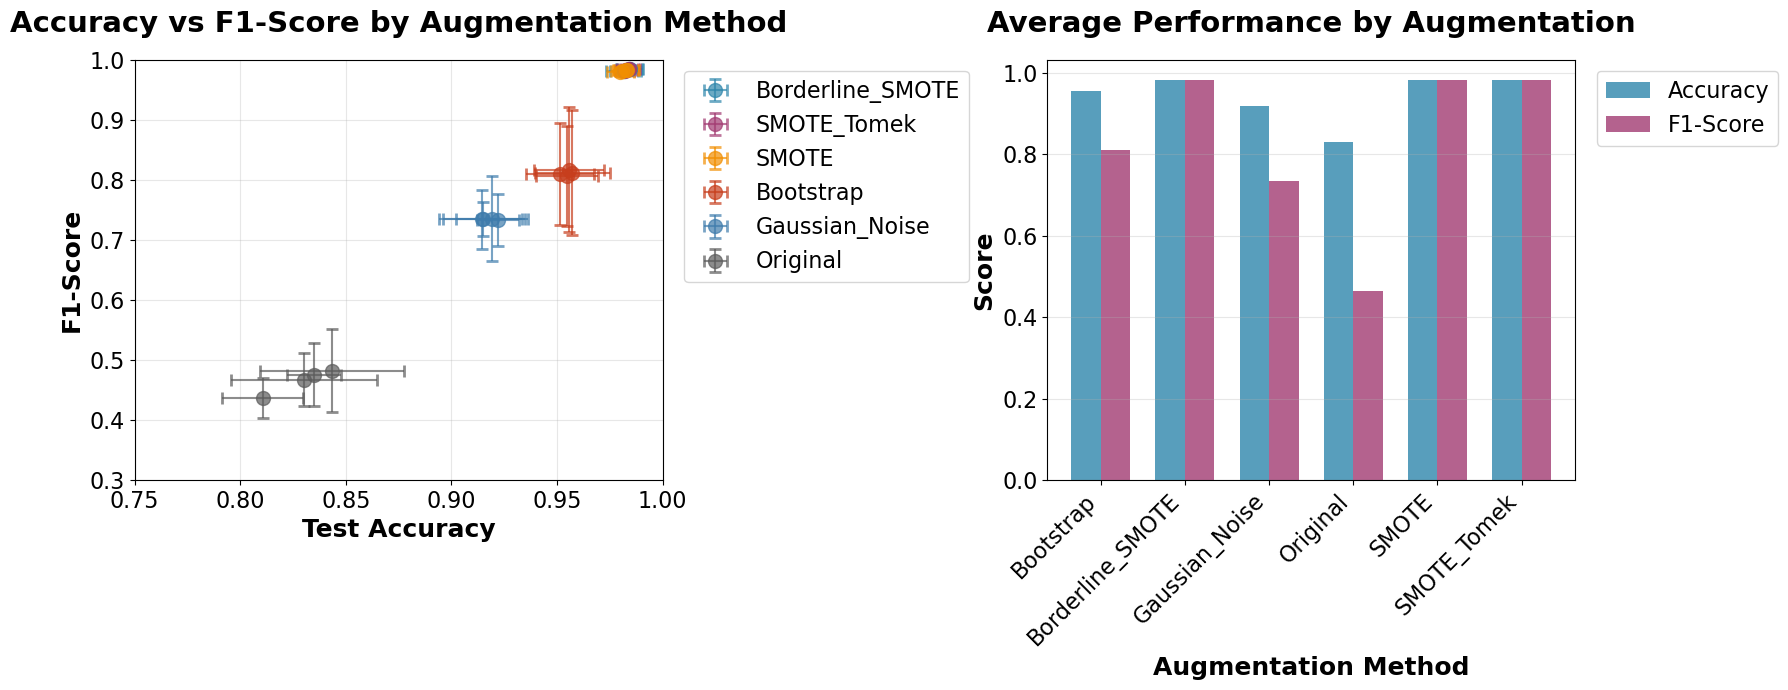

In [22]:
create_performance_comparison()
